In [1]:
import sys; sys.path.insert(0, "..")
import json, pandas as pd, numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

sns.set_theme(style="whitegrid", palette="muted")

raw = pd.read_csv("../results/task1_raw_results.csv")
with open("../results/task1_metrics.json") as f:
    metrics = json.load(f)

zs = raw[raw["prompt_type"] == "zero_shot"].copy()
fs = raw[raw["prompt_type"] == "few_shot"].copy()
print(f"Zero-shot rows: {len(zs)} | Few-shot rows: {len(fs)}")

Zero-shot rows: 200 | Few-shot rows: 200


### Summary Table

In [3]:
summary = pd.DataFrame({
    "Metric": ["JSON Format Compliance", "Accuracy", "Macro-F1"],
    "Zero-Shot": [
        metrics["zero_shot"]["format_compliance_rate"],
        metrics["zero_shot"]["accuracy"],
        metrics["zero_shot"]["macro_f1"],
    ],
    "Few-Shot": [
        metrics["few_shot"]["format_compliance_rate"],
        metrics["few_shot"]["accuracy"],
        metrics["few_shot"]["macro_f1"],
    ],
})
print(summary.to_string(index=False))

                Metric  Zero-Shot  Few-Shot
JSON Format Compliance     1.0000     1.000
              Accuracy     0.6200     0.650
              Macro-F1     0.6006     0.639


### Confusion Matrix 

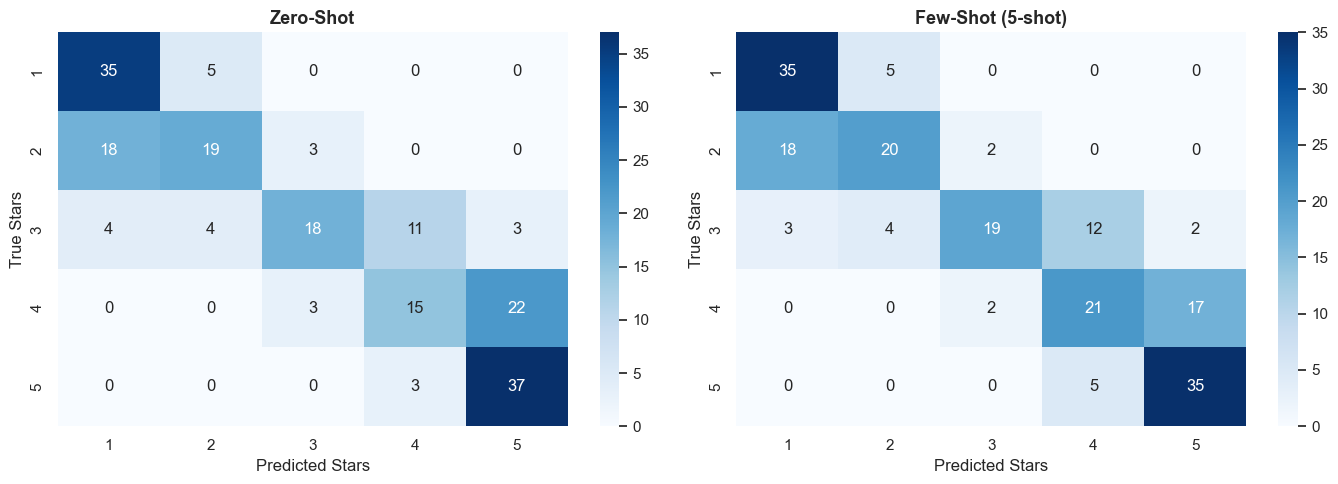

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, df_, title in zip(axes, [zs, fs], ["Zero-Shot", "Few-Shot (5-shot)"]):
    valid = df_[df_["pred_stars"].notna()].copy()
    valid["pred_stars"] = valid["pred_stars"].astype(int)
    cm = confusion_matrix(valid["true_stars"], valid["pred_stars"], labels=[1,2,3,4,5])
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
                xticklabels=[1,2,3,4,5], yticklabels=[1,2,3,4,5])
    ax.set_title(title, fontsize=13, fontweight="bold")
    ax.set_xlabel("Predicted Stars"); ax.set_ylabel("True Stars")
plt.tight_layout()
plt.savefig("../results/task1_confusion_matrices.png", dpi=150)
plt.show()

# per class F1 score  

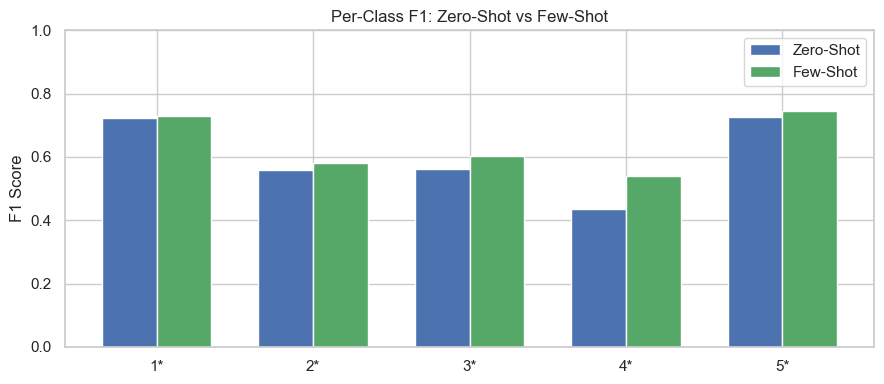

In [6]:
labels = ["1*", "2*", "3*", "4*", "5*"]
zs_f1 = [metrics["zero_shot"]["per_class_f1"][str(i)] for i in range(1,6)]
fs_f1 = [metrics["few_shot"]["per_class_f1"][str(i)] for i in range(1,6)]

x = np.arange(5); w = 0.35
fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(x - w/2, zs_f1, w, label="Zero-Shot", color="#4C72B0")
ax.bar(x + w/2, fs_f1, w, label="Few-Shot",  color="#55A868")
ax.set_xticks(x); ax.set_xticklabels(labels)
ax.set_ylabel("F1 Score"); ax.set_title("Per-Class F1: Zero-Shot vs Few-Shot")
ax.legend(); ax.set_ylim(0, 1)
plt.tight_layout()
plt.savefig("../results/task1_per_class_f1.png", dpi=150)
plt.show()

### ERROR ANALYSIS of model prediction failures 

In [7]:
for label, df_ in [("Zero-Shot", zs), ("Few-Shot", fs)]:
    valid = df_[df_["pred_stars"].notna()].copy()
    valid["pred_stars"] = valid["pred_stars"].astype(int)
    errors = valid[valid["pred_stars"] != valid["true_stars"]]
    print(f"\n{label} — {len(errors)} errors out of {len(valid)} valid predictions")
    print("  Confusion: true → predicted")
    print(errors.groupby(["true_stars", "pred_stars"]).size().sort_values(ascending=False).head(10))


Zero-Shot — 76 errors out of 200 valid predictions
  Confusion: true → predicted
true_stars  pred_stars
4           5             22
2           1             18
3           4             11
1           2              5
3           2              4
            1              4
2           3              3
3           5              3
4           3              3
5           4              3
dtype: int64

Few-Shot — 70 errors out of 200 valid predictions
  Confusion: true → predicted
true_stars  pred_stars
2           1             18
4           5             17
3           4             12
1           2              5
5           4              5
3           2              4
            1              3
2           3              2
4           3              2
3           5              2
dtype: int64


### Some failure examples

In [8]:
print("=== FAILURE EXAMPLES: Zero-Shot ===\n")
fails = zs[zs["pred_stars"] != zs["true_stars"]].dropna(subset=["pred_stars"]).head(5)
for _, row in fails.iterrows():
    print(f"TRUE: {int(row['true_stars'])}★ | PRED: {int(row['pred_stars'])}★")
    print(f"TEXT: {row['text_snippet'][:120]}...")
    print(f"EXPLANATION: {row['explanation']}")
    print()

=== FAILURE EXAMPLES: Zero-Shot ===

TRUE: 2★ | PRED: 1★
TEXT: We had lunch here yesterday, March 12th.  It was very disappointing, especially for the price paid.  My husband and I ea...
EXPLANATION: The reviewer was extremely dissatisfied with the overpriced and low-quality food and drinks, leading to a one-star rating.

TRUE: 3★ | PRED: 4★
TEXT: I might be finicky when it comes to Filipino food, but there is one thing that I cannot resist but getting from time to ...
EXPLANATION: The reviewer highly recommends the Pan De Ube and Pan De Sal, but notes that items tend to sell out quickly.

TRUE: 4★ | PRED: 5★
TEXT: Aria is typically not the type of establishment I would frequent. It seems like the type of place that people who think ...
EXPLANATION: The reviewer was pleasantly surprised by the excellent food, service, and ambiance, making it a great choice for a special occasion.

TRUE: 3★ | PRED: 1★
TEXT: Mediocre Chinese restaurant in Madison. Cliff and I came here for a cheat meal a